In [1]:
import os
os.chdir('./proj2_data/')

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
# Load your time series data
orig_df = pd.read_csv('weather_handout.csv')
orig_df.head()

,DATE,PRCP,SNOW,SNWD,TMAX,TMIN,TOBS
0,4/1/2023,0.00,0.0,0.0,73,68,68
1,4/2/2023,0.00,0.0,0.0,79,55,59
2,4/3/2023,1.11,0.0,0.0,81,55,71
3,4/4/2023,0.00,0.0,0.0,90,69,78
4,4/5/2023,0.18,0.0,0.0,89,64,64


In [4]:
orig_df.dtypes

DATE     object
PRCP    float64
SNOW    float64
SNWD    float64
TMAX      int64
TMIN      int64
TOBS      int64
dtype: object

## Cleaning data

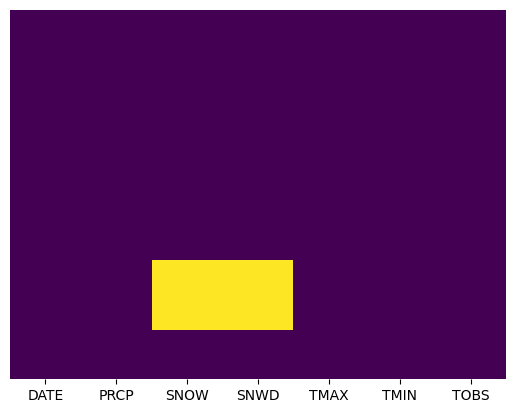

In [5]:
clean_df=orig_df.copy()
sns.heatmap(clean_df.isnull(),yticklabels=False,cbar=False,cmap='viridis')
plt.show()

In [6]:
null_percent = clean_df.isnull().sum()/len(clean_df)*100
null_percent

DATE     0.000000
PRCP     0.000000
SNOW    18.962963
SNWD    18.962963
TMAX     0.000000
TMIN     0.000000
TOBS     0.000000
dtype: float64

In [7]:
print("-- SNOW --\n", clean_df['SNOW'].tolist())
print("\n-- SNWD --\n", clean_df['SNWD'].tolist())

-- SNOW --
 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.

In [8]:
clean_df = clean_df.drop(columns=['SNOW', 'SNWD'])

#### String Time Format Code List: https://strftime.org/

In [9]:
df = clean_df.copy()
df['DATE'] = pd.to_datetime(df['DATE'], format='%m/%d/%Y')  # Match format according to the data pattern
df = df.sort_values(by="DATE")
df = df.set_index('DATE')
df.head()

,PRCP,TMAX,TMIN,TOBS
DATE,,,,
2023-04-01,0.00,73,68,68
2023-04-02,0.00,79,55,59
2023-04-03,1.11,81,55,71
2023-04-04,0.00,90,69,78
2023-04-05,0.18,89,64,64


In [10]:
df.tail()

,PRCP,TMAX,TMIN,TOBS
DATE,,,,
2025-03-27,0.00,83,45,65
2025-03-28,0.00,71,62,64
2025-03-29,0.65,75,64,66
2025-03-30,0.65,72,54,54
2025-03-31,0.86,73,54,54


Index(['PRCP', 'TMAX', 'TMIN', 'TOBS'], dtype='object')


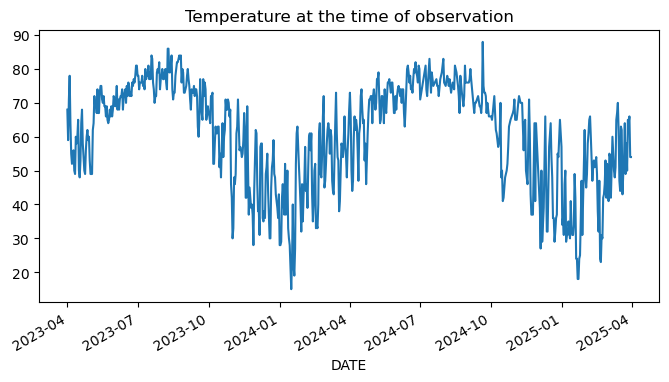

In [11]:
print(df.columns)
value_var = 'TOBS'
df[value_var].plot(title="Temperature at the time of observation", figsize=(8,4))
plt.show()

### Data Processing

In [12]:
# Detecting and removing outliers using Z-score
from scipy.stats import zscore
z_scores = zscore(df[value_var])
abs_z_scores = np.abs(z_scores)

zscore_threshold = 3 #any data above mean +/- (this_threshold)*sd is considered outliers
outliers = (abs_z_scores > zscore_threshold)  # Z-score threshold.
df = df.loc[~outliers].copy()

print(orig_df.shape)
print(df.shape)

df.head()

(675, 7)
(675, 4)


,PRCP,TMAX,TMIN,TOBS
DATE,,,,
2023-04-01,0.00,73,68,68
2023-04-02,0.00,79,55,59
2023-04-03,1.11,81,55,71
2023-04-04,0.00,90,69,78
2023-04-05,0.18,89,64,64


In [13]:
train = df.loc[df.index <= '2024-12-31']
test = df.loc[df.index > '2024-12-31']
forecast_steps = len(test)
train

,PRCP,TMAX,TMIN,TOBS
DATE,,,,
2023-04-01,0.00,73,68,68
2023-04-02,0.00,79,55,59
2023-04-03,1.11,81,55,71
2023-04-04,0.00,90,69,78
2023-04-05,0.18,89,64,64
...,...,...,...,...
2024-12-25,0.00,60,30,37
2024-12-26,0.00,64,34,55
2024-12-27,0.12,55,47,54


### Decomposition

<Figure size 2000x800 with 0 Axes>

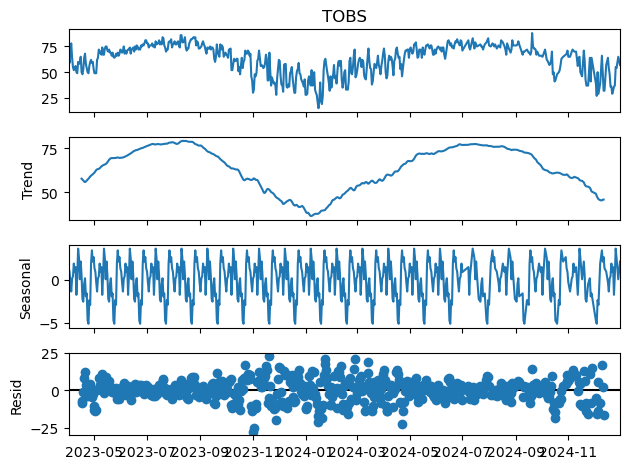

In [14]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition = seasonal_decompose(train[value_var], model='additive', period=30)
fig = plt.figure(figsize=(20,8))  
decomposition.plot()  
plt.show()

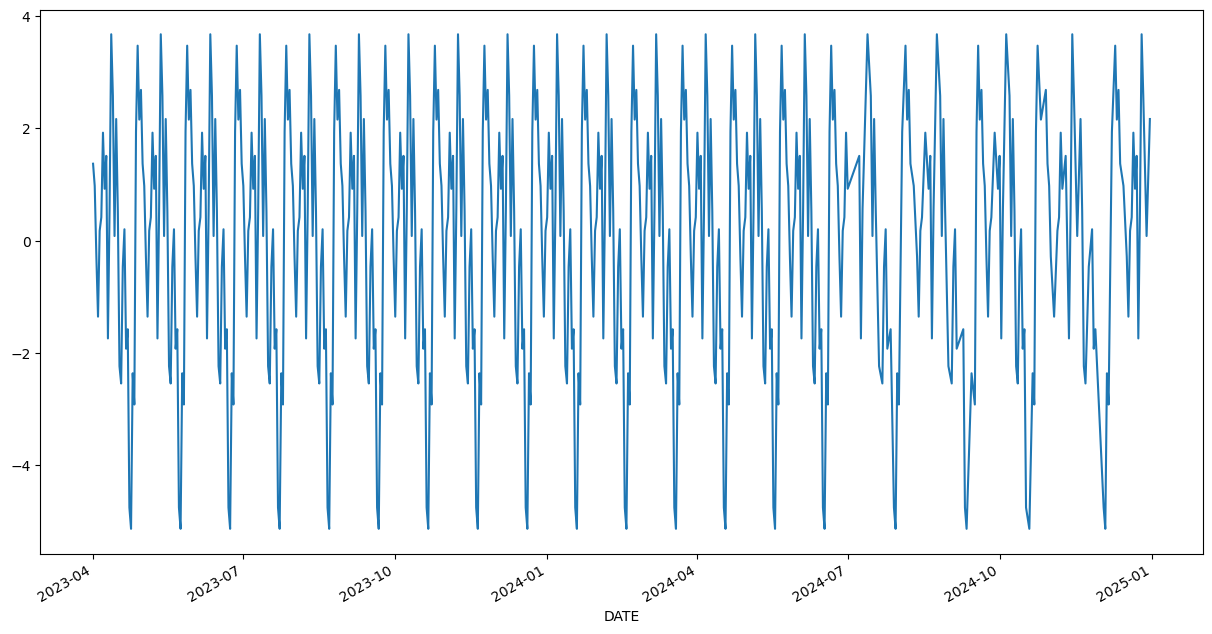

In [15]:
fig = plt.figure(figsize=(15,8))  
decomposition.seasonal.plot()
plt.show()

In [16]:
# Set selected_s for ARIMA model
selected_s = 30

### Find differencing d

In [17]:
from statsmodels.tsa.stattools import adfuller # ADF test
result = adfuller(train[value_var])
result

(np.float64(-1.861624716598395),
 np.float64(0.35032369206610486),
 11,
 573,
 {'1%': np.float64(-3.4418139386911513),
  '5%': np.float64(-2.866597262008035),
  '10%': np.float64(-2.5694633721967906)},
 np.float64(3795.0263496182206))

In [18]:
def test_adfuller(series, alpha=0.05):
    from statsmodels.tsa.stattools import adfuller
    result = adfuller(series)
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])
    for key, value in result[4].items():
        print(f"Critical Value ({key}): {value}")
    if result[1] <= alpha:
        print("Reject the null hypothesis. Data is stationary")
    else:
        print("Do not reject the null hypothesis. Data is not stationary ")

In [19]:
test_adfuller(train[value_var])

ADF Statistic: -1.861624716598395
p-value: 0.35032369206610486
Critical Value (1%): -3.4418139386911513
Critical Value (5%): -2.866597262008035
Critical Value (10%): -2.5694633721967906
Do not reject the null hypothesis. Data is not stationary 


In [20]:
# train['first_difference'].loc(train[value_var] - train[value_var].shift(1)).dropna()
# or you can use 
train.loc[:, 'first_difference'] = df[value_var].diff().dropna()  # diff() = compute difference between t and t-1
train['first_difference'].head()

/tmp/ipykernel_99136/1097910817.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train.loc[:, 'first_difference'] = df[value_var].diff().dropna()  # diff() = compute difference between t and t-1


DATE
2023-04-01     NaN
2023-04-02    -9.0
2023-04-03    12.0
2023-04-04     7.0
2023-04-05   -14.0
Name: first_difference, dtype: float64

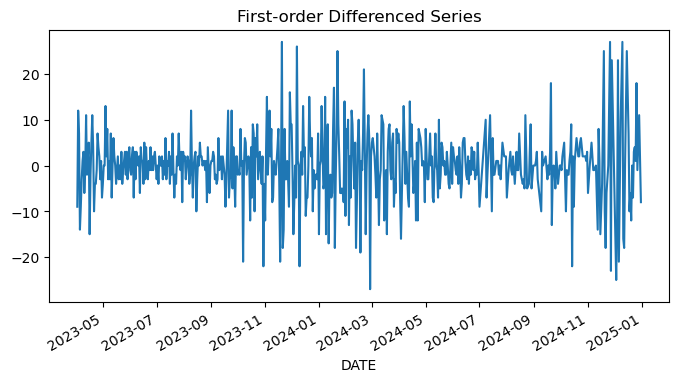

In [21]:
train['first_difference'].plot(title="First-order Differenced Series", figsize=(8,4))
plt.show()

In [22]:
test_adfuller(train['first_difference'].dropna())

ADF Statistic: -8.209956633582395
p-value: 6.860975741139439e-13
Critical Value (1%): -3.441935806025943
Critical Value (5%): -2.8666509204896093
Critical Value (10%): -2.5694919649816947
Reject the null hypothesis. Data is stationary


In [23]:
# Set selected_d for ARIMA/SARIMA model
selected_d = 1

### Find differencing D for seasonal timeseries 

In [24]:
# Skip this section if timeseries is not seasonal

/tmp/ipykernel_99136/3854906546.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train.loc[:, 'seasonal_difference'] = train[value_var] - train[value_var].shift(selected_s)


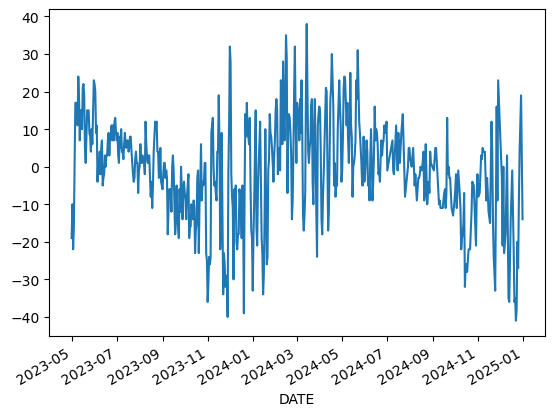

In [25]:
train.loc[:, 'seasonal_difference'] = train[value_var] - train[value_var].shift(selected_s)
train['seasonal_difference'].plot()
plt.show()

In [26]:
test_adfuller(train['seasonal_difference'].dropna())

ADF Statistic: -2.2327282575362535
p-value: 0.19458209187524822
Critical Value (1%): -3.442563336759378
Critical Value (5%): -2.866927190004947
Critical Value (10%): -2.5696391843672695
Do not reject the null hypothesis. Data is not stationary 


/tmp/ipykernel_99136/875153250.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train.loc[:, 'seasonal_first_difference'] = train['first_difference'] - train['first_difference'].shift(selected_s)


<Axes: xlabel='DATE'>

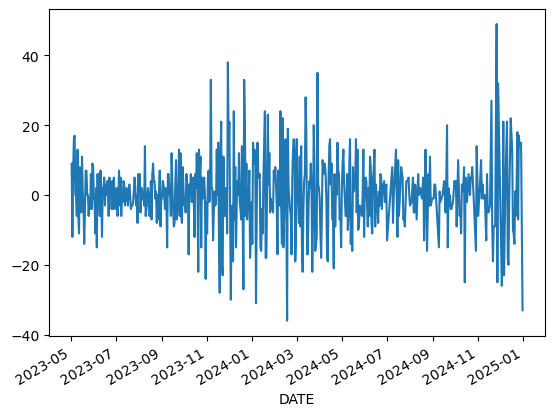

In [27]:
train.loc[:, 'seasonal_first_difference'] = train['first_difference'] - train['first_difference'].shift(selected_s)
train['seasonal_first_difference'].plot()

In [28]:
test_adfuller(train['seasonal_first_difference'].dropna())

ADF Statistic: -10.48495588917375
p-value: 1.1869692519258742e-18
Critical Value (1%): -3.442563336759378
Critical Value (5%): -2.866927190004947
Critical Value (10%): -2.5696391843672695
Reject the null hypothesis. Data is stationary


In [29]:
# Set selected_D for SARIMA model
selected_D = 1

### Identify p and q from PACF and ACF

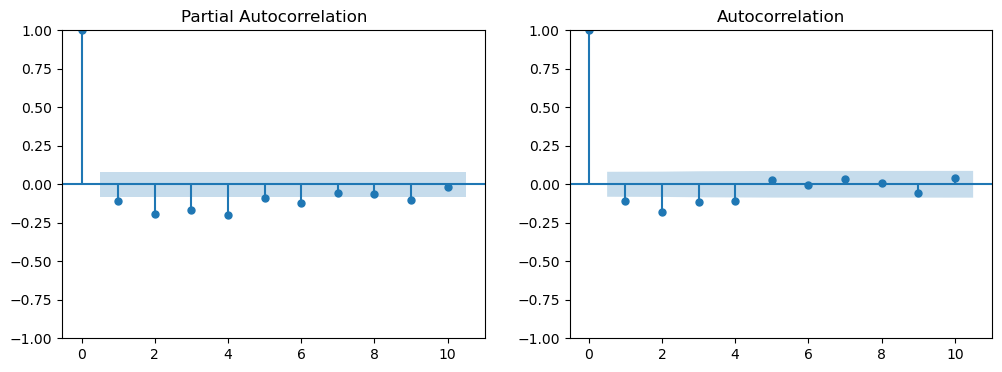

In [30]:
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf

fig, ax = plt.subplots(1, 2, figsize=(12,4))

plot_pacf(train['first_difference'].dropna(), lags=10, ax=ax[0])
plot_acf(train['first_difference'].dropna(), lags=10, ax=ax[1])

plt.show()

In [31]:
# Set possible selected_p and selected_q for ARIMA/SARIMA model
# the blue area is the confidental region
selected_p = 1
selected_q = 1

### Identify P and Q from PACF and ACF for seasonal timeseries

In [32]:
# Skip this section if timeseries is not seasonal

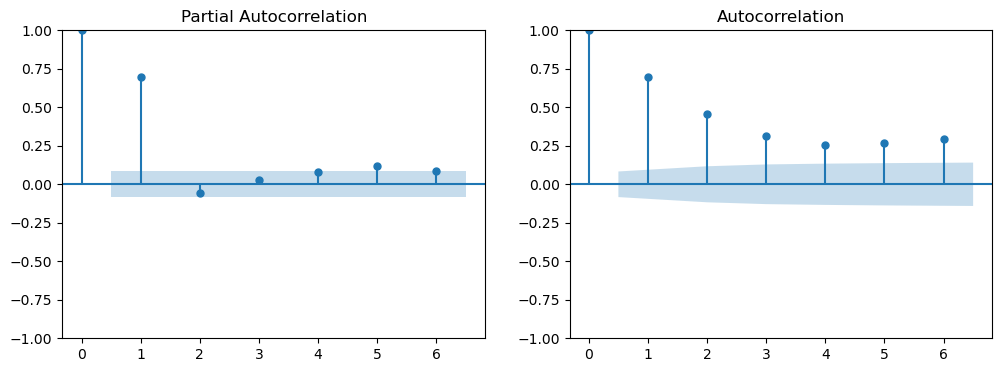

In [33]:
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf

fig, ax = plt.subplots(1, 2, figsize=(12,4))

plot_pacf(train['seasonal_difference'].dropna(), lags=6, ax=ax[0])
plot_acf(train['seasonal_difference'].dropna(), lags=6, ax=ax[1])

plt.show()

In [34]:
# Set possible selected_P and selected_Q for SARIMA model
selected_P = 1
selected_Q = 0

### Select SARIMA model based on AIC and BIC

In [35]:
# Set frequeuncy of time index 
# Frequenct String: https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html#offset-aliases
# train.index = pd.DatetimeIndex(train.index, freq='D')
train = train.asfreq('D')
train.index.inferred_freq

'D'

In [36]:
print(selected_s, selected_d, selected_D)
print(selected_p, selected_q)
print(selected_P, selected_Q)

30 1 1
1 1
1 0


In [37]:
# Create all possible choices for p and q
start_p = 0
end_p = 1
start_q = 0
end_q = 1
start_P = 0
end_P = 1
start_Q = 0
end_Q = 0

pdq_choices = []
for pi in range(start_p, end_p+1):
    for qi in range(start_q, end_q+1):
        for Pi in range(start_P, end_P+1):
            for Qi in range(start_Q, end_Q+1):
                pdq_choice = (pi, selected_d, qi)
                PDQ_choice = (Pi, selected_D, Qi, selected_s)
                
                pdq_choices.append([pdq_choice, PDQ_choice])
print(pdq_choices)

[[(0, 1, 0), (0, 1, 0, 30)], [(0, 1, 0), (1, 1, 0, 30)], [(0, 1, 1), (0, 1, 0, 30)], [(0, 1, 1), (1, 1, 0, 30)], [(1, 1, 0), (0, 1, 0, 30)], [(1, 1, 0), (1, 1, 0, 30)], [(1, 1, 1), (0, 1, 0, 30)], [(1, 1, 1), (1, 1, 0, 30)]]


In [38]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
# from statsmodels.stats.diagnostic import acorr_ljungbox
# from statsmodels.stats.diagnostic import het_arch
# from statsmodels.stats.stattools import jarque_bera

for pdq_choice in pdq_choices:
    try:
        print(pdq_choice)
        model = SARIMAX(train[value_var],order=pdq_choice[0], seasonal_order=pdq_choice[1])
        model_fit = model.fit()
        
        # obtain prob(Q)
        # lb = acorr_ljungbox(model_fit.resid, lags=[10], return_df=True)
        # prob_Q = lb['lb_pvalue'].iloc[0]
        # obtain prob(H)
        # prob_H = het_arch(model_fit.resid)[1]
        # obtain prob(JB)
        # jb_stat, prob_JB, skew, kurt = jarque_bera(model_fit.resid)

        # obtain prob(Q), prob(H), prob(JB)
        prob_Q = model_fit.test_serial_correlation(method='ljungbox')[0][1][0]
        prob_H = model_fit.test_heteroskedasticity(method='breakvar')[0][1]
        prob_JB = model_fit.test_normality(method='jarquebera')[0][1]
    
        print(pdq_choice, ", AIC:", model_fit.aic, ", Prob(Q):", prob_Q, ", Prob(H):", prob_H)
        print(model_fit.pvalues)
    except:
        continue

#===============================
# ar.L1: Strength of dependence on previous value
#        p-value < 0.05 -> AR term is statistically significant
#                        If insignificant → AR term may be unnecessary
# ma.L1: Captures shock/error correction
#        p-value < 0.05 → MA term contributes meaningfully
#                        If insignificant → MA term may be unnecessary#
# sigma² (noise variance): Variance of residuals
#        Smaller = model explains more structure
#===============================
# Ljung–Box: Test whether residuals are white noise
#            H0: residuals are uncorrelated
#            If p-value (Prob(Q)) > 0.05 -> residuals ≈ white noise -> ARIMA remove all temporal structure
# Heteroskedasticity (H): Test  whether variance of residuals is constant
#                         If p-value (Prob(H)) > 0.05 -> contant variance 
# Jarque-Bera (JB): Test whether residuals are normality
#                   If p-value (Prob(JB)) > 0.05 -> residuals roughly normal
#===============================

[(0, 1, 0), (0, 1, 0, 30)]
[(0, 1, 0), (0, 1, 0, 30)] , AIC: 4167.911813675506 , Prob(Q): 0.36602739186124256 , Prob(H): 0.6096123952576008
sigma2    3.587083e-108
dtype: float64
[(0, 1, 0), (1, 1, 0, 30)]
[(0, 1, 0), (1, 1, 0, 30)] , AIC: 4018.7229169221855 , Prob(Q): 0.3670201044107023 , Prob(H): 0.7537850846620991
ar.S.L30     2.506571e-71
sigma2      1.507381e-103
dtype: float64
[(0, 1, 1), (0, 1, 0, 30)]
[(0, 1, 1), (0, 1, 0, 30)] , AIC: 4167.409396329094 , Prob(Q): 0.4353256688524032 , Prob(H): 0.6532842399189049
ma.L1      4.550163e-03
sigma2    1.131354e-105
dtype: float64
[(0, 1, 1), (1, 1, 0, 30)]
[(0, 1, 1), (1, 1, 0, 30)] , AIC: 4019.067705788409 , Prob(Q): 0.654192523933923 , Prob(H): 0.7788391250850686
ma.L1        3.176881e-02
ar.S.L30     5.195388e-68
sigma2      1.114849e-100
dtype: float64
[(1, 1, 0), (0, 1, 0, 30)]
[(1, 1, 0), (0, 1, 0, 30)] , AIC: 4168.5820904736665 , Prob(Q): 0.986874333093456 , Prob(H): 0.6375493013046275
ar.L1      1.462645e-01
sigma2    5.392083

/nix/store/fqm2yfxsaigixmzyzbw9whdvnwi2mxjg-devenv-profile/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


[(1, 1, 1), (0, 1, 0, 30)] , AIC: 4072.3478258894493 , Prob(Q): 0.006502596872784365 , Prob(H): 0.8009235736776482
ar.L1     1.824876e-83
ma.L1     0.000000e+00
sigma2    1.238656e-87
dtype: float64
[(1, 1, 1), (1, 1, 0, 30)]


/nix/store/fqm2yfxsaigixmzyzbw9whdvnwi2mxjg-devenv-profile/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


[(1, 1, 1), (1, 1, 0, 30)] , AIC: 3931.1160037394375 , Prob(Q): 0.010475974322885304 , Prob(H): 0.9762217977184823
ar.L1       6.271719e-72
ma.L1       0.000000e+00
ar.S.L30    4.865235e-56
sigma2      2.584167e-89
dtype: float64


/nix/store/fqm2yfxsaigixmzyzbw9whdvnwi2mxjg-devenv-profile/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/nix/store/fqm2yfxsaigixmzyzbw9whdvnwi2mxjg-devenv-profile/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


[(1, 1, 0), (1, 1, 0, 30)] , RMSE: 17.686259727652242 , MAE : 14.708662527178566


/nix/store/fqm2yfxsaigixmzyzbw9whdvnwi2mxjg-devenv-profile/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/nix/store/fqm2yfxsaigixmzyzbw9whdvnwi2mxjg-devenv-profile/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


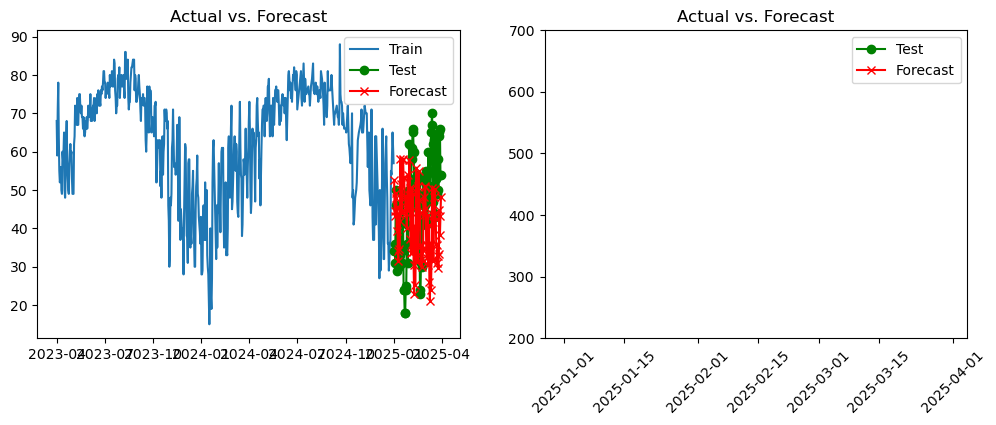

In [60]:
pdq_choice = [(1, 1, 0), (1, 1, 0, 30)]

model = SARIMAX(train[value_var],order=pdq_choice[0], seasonal_order=pdq_choice[1])
model_fit = model.fit()
forecast = model_fit.forecast(steps=forecast_steps)

# aligne index
# forecast = np.exp(log_forecast)
forecast.index = test.index

from sklearn.metrics import mean_squared_error, mean_absolute_error
rmse = np.sqrt(mean_squared_error(test[value_var], forecast))
mae = mean_absolute_error(test[value_var], forecast)

print(pdq_choice, ", RMSE:", rmse, ", MAE :", mae)

fig, ax = plt.subplots(1, 2, figsize=(12,4))

ax[0].plot(train[value_var], label="Train")
ax[0].plot(test[value_var], label="Test", marker="o", color='green')
ax[0].plot(test.index, forecast, label="Forecast", marker="x", color='red')
ax[0].legend()
ax[0].set_title("Actual vs. Forecast")

ax[1].plot(test[value_var], label="Test", marker="o", color='green')
ax[1].plot(test.index, forecast, label="Forecast", marker="x", color='red')
ax[1].legend()
ax[1].set_title("Actual vs. Forecast")
ax[1].tick_params(axis='x', labelrotation=45)
ax[1].set_ylim([200, 700])
    
plt.show()

In [61]:
pdq_choice = [(1, 1, 0), (1, 1, 0, 30)]

model = SARIMAX(train[value_var],order=pdq_choice[0], seasonal_order=pdq_choice[1])
model_fit = model.fit()
forecast = model_fit.forecast(steps=forecast_steps)
# forecast = np.exp(log_forecast)
print(model_fit.summary())

/nix/store/fqm2yfxsaigixmzyzbw9whdvnwi2mxjg-devenv-profile/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/nix/store/fqm2yfxsaigixmzyzbw9whdvnwi2mxjg-devenv-profile/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                               TOBS   No. Observations:                  585
Model:             SARIMAX(1, 1, 0)x(1, 1, 0, 30)   Log Likelihood               -2010.486
Date:                            Sun, 29 Mar 2026   AIC                           4026.972
Time:                                    23:20:59   BIC                           4039.924
Sample:                                         0   HQIC                          4032.032
                                            - 585                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0765      0.033     -2.334      0.020      -0.141      -0.012
ar.S.L30      -0.5236      0.031   

/nix/store/fqm2yfxsaigixmzyzbw9whdvnwi2mxjg-devenv-profile/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/nix/store/fqm2yfxsaigixmzyzbw9whdvnwi2mxjg-devenv-profile/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


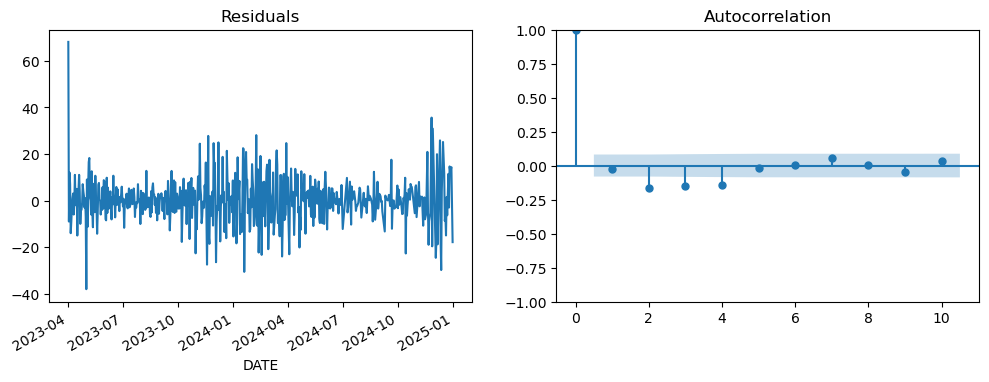

In [62]:
fig, ax = plt.subplots(1, 2, figsize=(12,4))

residuals = model_fit.resid
residuals.plot(title="Residuals", ax=ax[0])
plot_acf(residuals, lags=10, ax=ax[1])
plt.show()

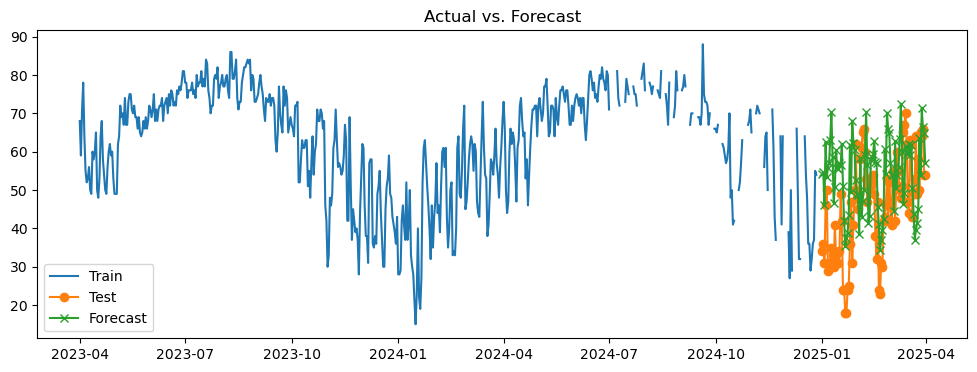

In [42]:
plt.figure(figsize=(12,4))
plt.plot(train[value_var], label="Train")
plt.plot(test[value_var], label="Test", marker="o")
plt.plot(test.index, forecast, label="Forecast", marker="x")
plt.legend()
plt.title("Actual vs. Forecast")
plt.savefig("../src/forecast_SARIMA.jpg")
plt.show()

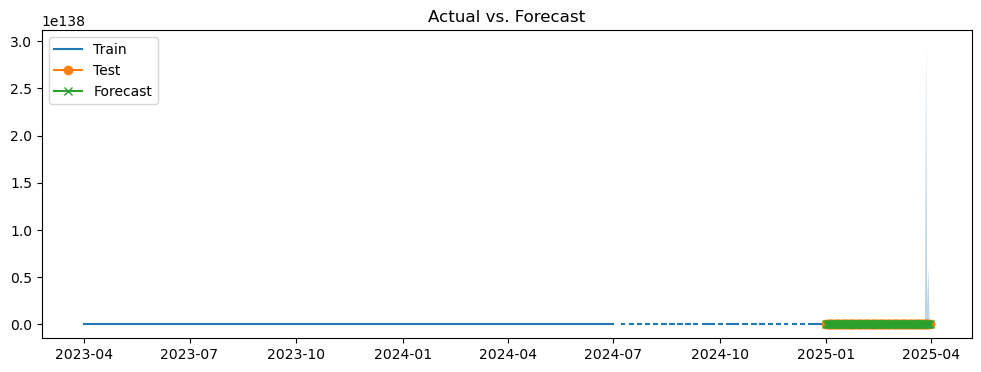

In [43]:
# Plot with confidence intervals of forecasting values

plt.figure(figsize=(12,4))

# Confidence intervals
model_forecast = model_fit.get_forecast(steps=forecast_steps)
forecast_mean = np.exp(model_forecast.predicted_mean)           # Predicted values, same result as model_fit.forecast(steps=forecast_steps)
forecast_ci = np.exp(model_forecast.conf_int())

plt.plot(train[value_var], label="Train")
plt.plot(test[value_var], label="Test", marker="o")
plt.plot(forecast_mean, label="Forecast", marker="x")

# Plot confidence intervals
plt.fill_between(
    forecast_ci.index,
    forecast_ci.iloc[:, 0],
    forecast_ci.iloc[:, 1],
    alpha=0.3
)

plt.legend()
plt.title("Actual vs. Forecast")
plt.show()

In [44]:
# The results of confidence intervals is not forecasted well, as you see from the graph plot.

### LSTM with Lags

In [45]:
value_var = 'TOBS'

In [46]:
def create_lags(data, lags=12):
    df_lag = pd.DataFrame(index=data.index)

    for i in range(1, lags+1):
        df_lag[f'lag_{i}'] = data.shift(i)

    df_lag['y'] = data
    return df_lag.dropna()

data = create_lags(df[value_var], lags=12)
data.head()

,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_10,lag_11,lag_12,y
DATE,,,,,,,,,,,,,
2023-04-13,60.0,49.0,50.0,56.0,53.0,52.0,55.0,64.0,78.0,71.0,59.0,68.0,58
2023-04-14,58.0,60.0,49.0,50.0,56.0,53.0,52.0,55.0,64.0,78.0,71.0,59.0,60
2023-04-15,60.0,58.0,60.0,49.0,50.0,56.0,53.0,52.0,55.0,64.0,78.0,71.0,65
2023-04-16,65.0,60.0,58.0,60.0,49.0,50.0,56.0,53.0,52.0,55.0,64.0,78.0,50
2023-04-17,50.0,65.0,60.0,58.0,60.0,49.0,50.0,56.0,53.0,52.0,55.0,64.0,48


In [47]:
from sklearn.preprocessing import StandardScaler

data = df[value_var].values.astype('float32')
data = data.reshape(-1,1)
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data).flatten()

In [48]:
def create_sequences(data, window=12):
    X, y = [], []
    for i in range(len(data)-window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

X, y = create_sequences(data_scaled, window=14)

In [49]:
X = X.reshape((X.shape[0], X.shape[1], 1))
split = int(len(X)*0.7)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [50]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

window = 14
lstm = Sequential([
    LSTM(32, activation='tanh', input_shape=(window,1)),
    Dense(1)
])

lstm.compile(optimizer='adam', loss='mse')

lstm.fit(X_train, y_train, epochs=100, verbose=1)

I0000 00:00:1774801246.711138   99136 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Epoch 1/100


E0000 00:00:1774801247.913812   99136 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
I0000 00:00:1774801247.913834   99136 cuda_diagnostics.cc:171] verbose logging is disabled. Rerun with verbose logging (usually --v=1 or --vmodule=cuda_diagnostics=1) to get more diagnostic output from this module
I0000 00:00:1774801247.913836   99136 cuda_diagnostics.cc:176] retrieving CUDA diagnostic information for host: hamham
I0000 00:00:1774801247.913839   99136 cuda_diagnostics.cc:183] hostname: hamham
I0000 00:00:1774801247.913918   99136 cuda_diagnostics.cc:190] libcuda reported version is: NOT_FOUND: was unable to find libcuda.so DSO loaded into this program. The library may be missing or provided via another object.
I0000 00:00:1774801247.913938   99136 cuda_diagnostics.cc:194] kernel reported version is: 595.45.4
/home/tako/Kasetsart/statistics/.devenv/state/venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserW

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6998   
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3976 
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3107 
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2845 
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2814 
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2781 
Epoch 7/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2718 
Epoch 8/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2703 
Epoch 9/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2661 
Epoch 10/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2619 
Epoch 11/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2588 
Epoch 12/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2557 
Epoch 13/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2525 
Epoch 14/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2494 
Epoch 15/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2465 

In [51]:
lstm_predictions = lstm.predict(X_test)

y_test_inv  = scaler.inverse_transform(y_test.reshape(-1,1))
lstm_predictions_inv  = scaler.inverse_transform(lstm_predictions)

# Evaluation
from sklearn.metrics import mean_squared_error
rmse = np.sqrt(mean_squared_error(y_test_inv, lstm_predictions_inv))
mae = mean_absolute_error(y_test_inv, lstm_predictions_inv)
print("RMSE:", rmse, ", MAE :", mae)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
RMSE: 8.929666567533427 , MAE : 6.63299036026001


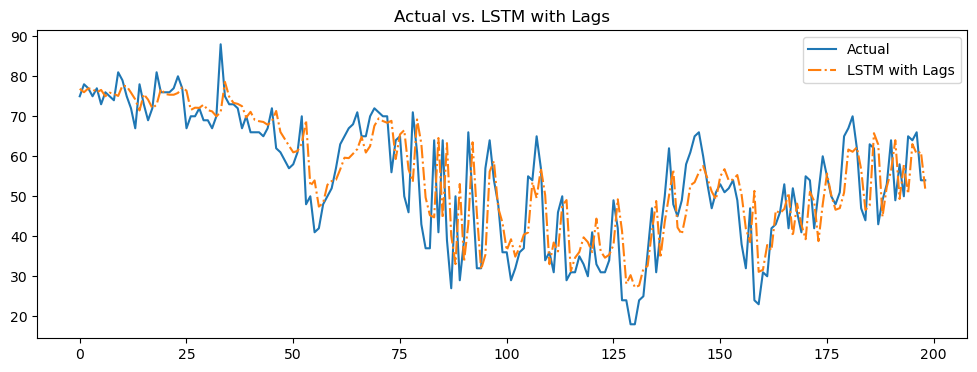

In [52]:
plt.figure(figsize=(12,4))
plt.plot(y_test_inv, label="Actual")
plt.plot(lstm_predictions_inv, '-.', label="LSTM with Lags")
plt.legend(['Actual', 'LSTM with Lags'])
plt.title('Actual vs. LSTM with Lags')
plt.show()

### RNN with features

In [53]:
df.columns

Index(['PRCP', 'TMAX', 'TMIN', 'TOBS'], dtype='object')

In [54]:
train = df.loc[df.index <= '2024-12-31']
test = df.loc[df.index > '2024-12-31']
forecast_steps = len(test)

FEATURES = ['TMAX', 'TMIN', 'PRCP']
TARGET = 'TOBS'

X_train = train[FEATURES]
y_train = train[TARGET]

X_test = test[FEATURES]
y_test = test[TARGET]

In [55]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense


# Prepare your time series data (train_x, train_y)
train_x = np.array(X_train)  # input sequences
train_y = np.array(y_train)  # target values

# Reshape the data for RNN
train_x = train_x.reshape((train_x.shape[0], train_x.shape[1], 1))

# Build the RNN model
model = Sequential()
model.add(SimpleRNN(50, activation='relu', input_shape=(train_x.shape[1], 1)))
model.add(Dense(1))

# Compile and fit the model
model.compile(optimizer='adam', loss='mse')
model.fit(train_x, train_y, epochs=20, verbose=1)

Epoch 1/20


/home/tako/Kasetsart/statistics/.devenv/state/venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 1695.3651   
Epoch 2/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 88.1527 
Epoch 3/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 29.6676 
Epoch 4/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 24.0909 
Epoch 5/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 21.3083 
Epoch 6/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 20.5413
Epoch 7/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 20.2366 
Epoch 8/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 20.2628 
Epoch 9/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 20.3568 
Epoch 10/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 20.1913 
Epoch 11/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 20.0697 
Epoch 12/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 20.1036 
Epoch 13/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 20.0635 
Epoch 14/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 20.1634 
Epoch 15/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 19.978

In [56]:
# Predict values
test_x = np.array(X_test)  # input sequences
test_y = np.array(y_test)  # target values

predictions = model.predict(test_x)

# Evaluation
from sklearn.metrics import mean_squared_error
rmse = np.sqrt(mean_squared_error(test_y, predictions))
mae = mean_absolute_error(test_y, predictions)
print("RMSE:", rmse, ", MAE :", mae)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
RMSE: 5.027598886603345 , MAE : 4.159132480621338


/tmp/ipykernel_99136/585808477.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['rnn_prediction'] = predictions


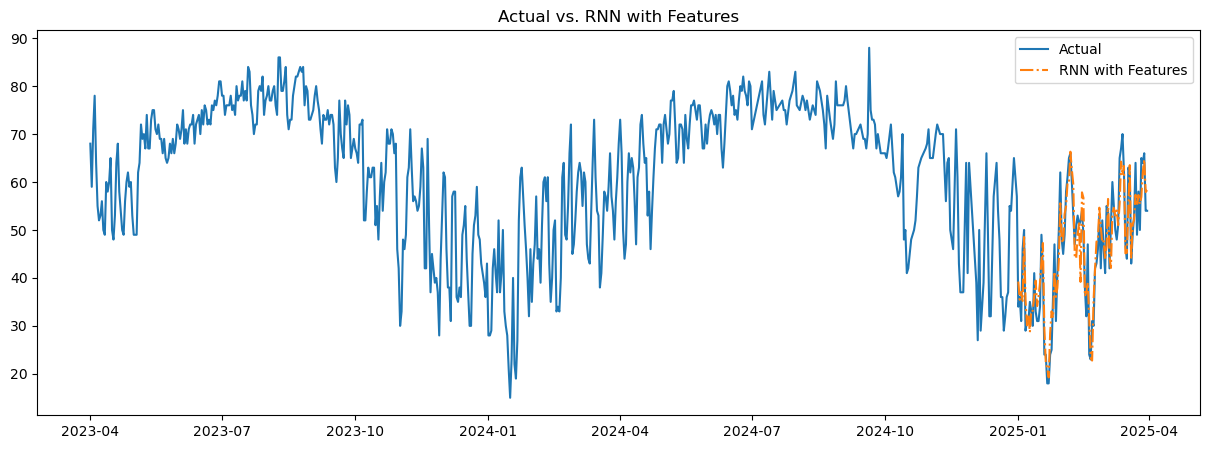

In [57]:
result = df.copy()
test['rnn_prediction'] = predictions
result = result.merge(test['rnn_prediction'], how='left', left_index=True, right_index=True)

plt.figure(figsize=(15,5))
plt.plot(result[[TARGET]])
plt.plot(test['rnn_prediction'], '-.')
plt.legend(['Actual', 'RNN with Features'])
plt.title('Actual vs. RNN with Features')
plt.savefig("../src/forecast_RNN_with_features.jpg")
plt.show()

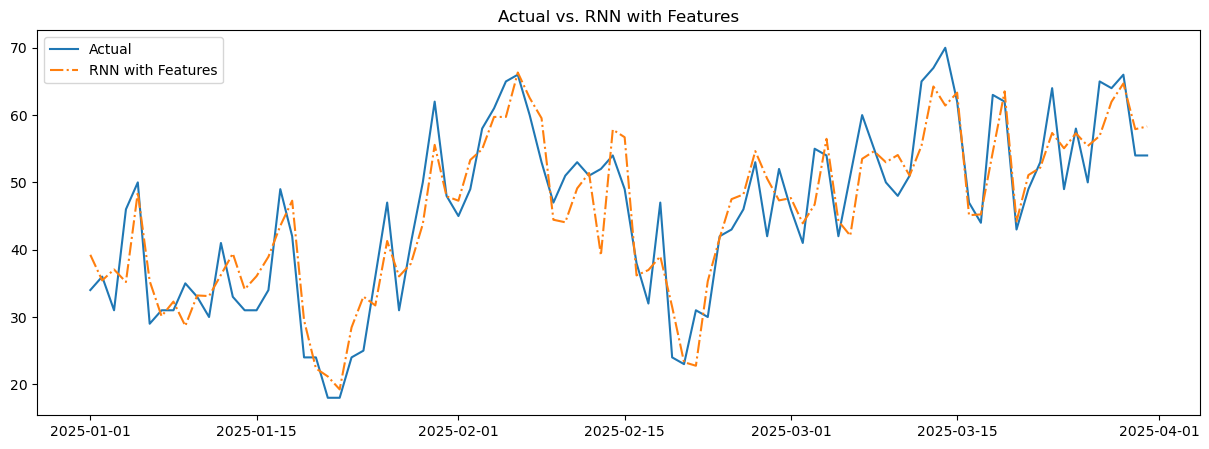

In [58]:
plt.figure(figsize=(15,5))
plt.plot(test[TARGET])
plt.plot(test['rnn_prediction'], '-.', label='RNN with Features')
plt.legend(['Actual', 'RNN with Features'])
plt.title('Actual vs. RNN with Features')
plt.show()